Goal of this notebook is to create a flexible pipeline that starts from a answered+labelled QA dataset and:

1. Computes semantic and response-graph level spectral features
2. Shows basic EDA plots/feature relationships
3. Evaluates performance of a logistic regression model with cross validation
4. Trains a logistic regression model
5. Inspects model outputs (coefficient stability, feature correlations)

We start by loading the data and aggregating responses to the question level.

In [1]:
import pandas as pd

df_orig = pd.read_json("defan_t0.9_n20.jsonl",lines=True)
df = df_orig.copy()
df.isna().sum()

id                   0
question             0
reference_answer     0
type                 0
domain               0
model_answer         0
dataset              0
correctness          0
adversarial          0
correctness_score    0
dtype: int64

In [2]:
df.head()

,id,question,reference_answer,type,domain,model_answer,dataset,correctness,adversarial,correctness_score
0,q_000_0,Who claimed the championship title in the 1950...,Uruguay,name,Humanities,Switzerland,defan,incorrect,False,1
1,q_000_1,Who claimed the championship title in the 1950...,Uruguay,name,Humanities,The 1950 FIFA World Cup title went to Uruguay.,defan,correct,False,5
2,q_000_2,Who claimed the championship title in the 1950...,Uruguay,name,Humanities,France,defan,incorrect,False,1
3,q_000_3,Who claimed the championship title in the 1950...,Uruguay,name,Humanities,USSR,defan,incorrect,False,1
4,q_000_4,Who claimed the championship title in the 1950...,Uruguay,name,Humanities,Uruguay.,defan,correct,False,5


In [3]:
df["correctness"].value_counts()

correctness
incorrect    7621
correct      2377
refused         2
Name: count, dtype: int64

In [4]:
# this block records correctness as a binary score, creates the question-level ids, and defines the target variables p_hat and y

df["label"] = (df["correctness"] != "correct").astype(int)
df["q_id"] = df["id"].str.rsplit("_", n=1).str[0]

question_df = (
    df
    .groupby("q_id")
    .agg(
        p_hat=("label", "mean"),
        n_samples=("label", "size")
    )
    .reset_index()
)

question_df["y"] = (question_df["p_hat"] > 0.5).astype(int)

df = df.merge(question_df[["q_id","p_hat","y"]], on="q_id", how="left")

In [5]:
# next we run the embedding and save to file

import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# note this model automatically normalizes the embedding vectors: signal is only carried in the relative directions

print(model)

# now construct the embedding matrix

embeddings = model.encode(
    df["model_answer"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# and save it to file

np.save("response_embeddings.npy", embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

** I am having trouble handling the refusal drops coherently, so I'm going to ignore it for now, but ideally we would have it setup so it doesnt matter if refusals get dropped the code will adapt to the new shape... i dont have time left to figure this out on my own **

In [7]:
# now we compute the feature matrix

from sklearn.cluster import AgglomerativeClustering

E = embeddings
E_grouped = E.reshape(500,20,384)

# write a function that computes and stores the cosine similarity matrices in an np array

def compute_cosine_matrices(e):
    return e @ e.transpose(0, 2, 1)

cosine_mats = compute_cosine_matrices(E_grouped)

# write a function that computes clusters for the given response ensembles

def cluster_gen(e, tau=0.85):
    n_questions = e.shape[0]
    clusters = []

    for i in range(n_questions):
        embeddings = e[i]
        clustering = AgglomerativeClustering(
            metric = "cosine",
            linkage = "average",
            distance_threshold = 1-tau,
            n_clusters = None
        )
        labels = clustering.fit_predict(embeddings)
        clusters.append(labels)
    return clusters

# now compute and store the entropy

def semantic_entropy(labels):
    counts = np.bincount(labels)
    probs = counts / counts.sum()
    return -(probs * np.log2(probs)).sum()

clusters = cluster_gen(E_grouped)
H_sem = np.array([semantic_entropy(c) for c in clusters])

# compute the centroid cosine dispersion

def centroid_cosine_dispersion(e):
    n_questions = e.shape[0]
    dispersions = []

    for i in range(n_questions):
        embeddings = e[i]
        centroid = embeddings.mean(axis=0)
        centroid = centroid / np.linalg.norm(centroid)
        D_cos = np.mean(1 - (embeddings @ centroid))
        dispersions.append(D_cos)
    return np.array(dispersions)

dispersions = centroid_cosine_dispersion(E_grouped)

# now do the cluster counts and similarity variance

def cluster_count(clusters):
    return np.array([len(np.unique(c)) for c in clusters])

K = cluster_count(clusters)


def similarity_variance(cosine_mats):
    n_q = cosine_mats.shape[0]
    iu = np.triu_indices(cosine_mats.shape[1], k=1) 
    out = np.empty(n_q)

    for i in range(n_q):
        vals = cosine_mats[i][iu]
        out[i] = np.var(vals)

    return out

S_var = similarity_variance(cosine_mats)

# ~~~ response-graph spectral features ~~~


def response_graph_spectral_features(S):

    W = np.clip(S, 0, None)
    np.fill_diagonal(W, 0)

    d = W.sum(axis=1)
    L = np.diag(d) - W

    evals, evecs = np.linalg.eigh(L)

    lam2 = evals[1]
    lam3 = evals[2]
    SGR = lam2 / (lam3 + 1e-8)

    q = evals / evals.sum()
    q = q[q > 0]
    HVN = -np.sum(q * np.log2(q))

    v2 = evecs[:,1]
    p = np.abs(v2)
    p = p / p.sum()
    p = p[p > 0]
    HFER = lam2 * (-np.sum(p * np.log2(p)))

    return lam2, SGR, HVN, HFER

def batch_response_graph_spectral_features(cosine_mats):
    n_q = cosine_mats.shape[0]
    lam2 = np.empty(n_q, dtype=float)
    SGR  = np.empty(n_q, dtype=float)
    HVN  = np.empty(n_q, dtype=float)
    HFER  = np.empty(n_q, dtype=float)

    for i in range(n_q):
        lam2[i], SGR[i], HVN[i], HFER[i] = response_graph_spectral_features(cosine_mats[i])

    return lam2, SGR, HVN, HFER

lam2, SGR, HVN, HFER = batch_response_graph_spectral_features(cosine_mats)

# finally, construct the feature matrix X

X = np.column_stack([H_sem, dispersions, K, S_var, lam2, SGR, HVN, HFER])

2. Now we will show some EDA/feature relationships.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

p_hat = question_df["p_hat"]
y = question_df["y"]
feature_names = ["H_sem", "dispersions", "K", "S_var", "lam2", "SGR", "HVN", "HFER"]

df_eda = pd.DataFrame(X, columns=feature_names)
df_eda["y"] = y
df_eda["p_hat"] = p_hat

display(df_eda[feature_names + ["p_hat", "y"]].describe().T)
print("Class balance y=1 fraction:", df_eda["y"].mean())

,count,mean,std,min,25%,50%,75%,max
H_sem,500.0,2.624359,1.250589,-0.000000,1.578771,2.921928,3.721928,4.321928
dispersions,500.0,0.250235,0.132616,0.003059,0.133955,0.262230,0.362406,0.513187
K,500.0,10.176000,5.545677,1.000000,5.000000,11.000000,15.000000,20.000000
S_var,500.0,0.048412,0.029019,0.000052,0.028806,0.044070,0.061136,0.178998
lam2,500.0,5.871361,3.994078,0.796497,2.831011,4.305697,8.347033,19.709133
SGR,500.0,0.762585,0.171561,0.143572,0.663817,0.806422,0.897581,0.999893
HVN,500.0,4.201247,0.037532,3.990070,4.183616,4.208264,4.230692,4.247923
HFER,500.0,20.088180,14.106923,2.465873,9.731929,15.340813,27.610120,84.548851
p_hat,500.0,0.762300,0.321559,0.000000,0.600000,0.950000,1.000000,1.000000
y,500.0,0.796000,0.403373,0.000000,1.000000,1.000000,1.000000,1.000000


Class balance y=1 fraction: 0.796


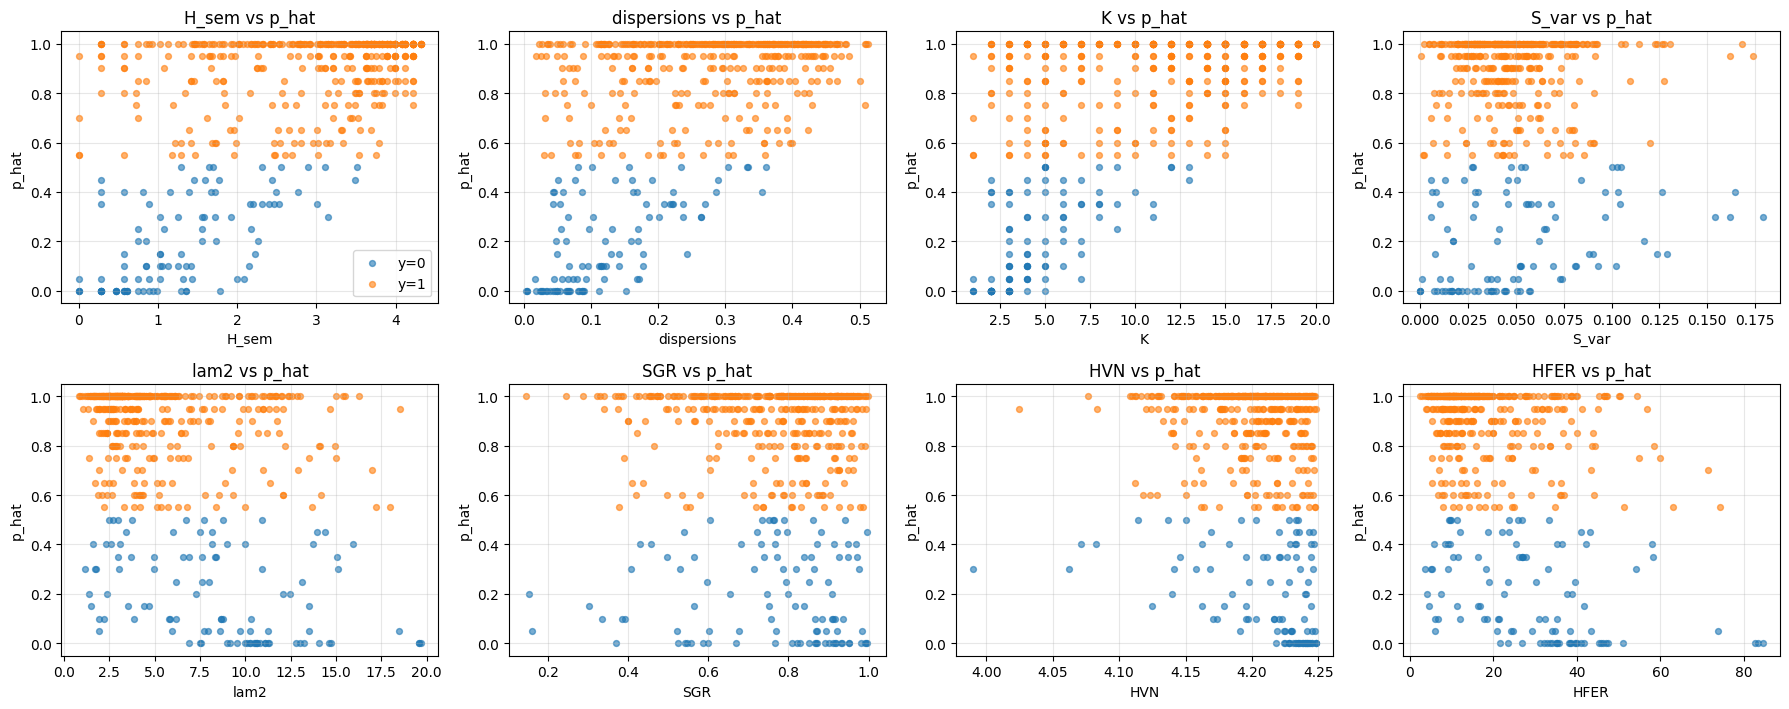

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def feature_vs_phat_grid(df, features, y_col="y", phat_col="p_hat"):
    n = len(features)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.6*nrows))
    axes = np.asarray(axes).reshape(-1)

    for i, f in enumerate(features):
        ax = axes[i]
        m0 = df[y_col] == 0
        m1 = df[y_col] == 1

        ax.scatter(df.loc[m0, f], df.loc[m0, phat_col], alpha=0.6, s=18, label="y=0")
        ax.scatter(df.loc[m1, f], df.loc[m1, phat_col], alpha=0.6, s=18, label="y=1")
        ax.set_title(f"{f} vs p_hat")
        ax.set_xlabel(f)
        ax.set_ylabel("p_hat")
        ax.grid(True, alpha=0.3)

        # Keep legend only once
        if i == 0:
            ax.legend()
        else:
            ax.legend().remove()

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

feature_vs_phat_grid(df_eda, feature_names)

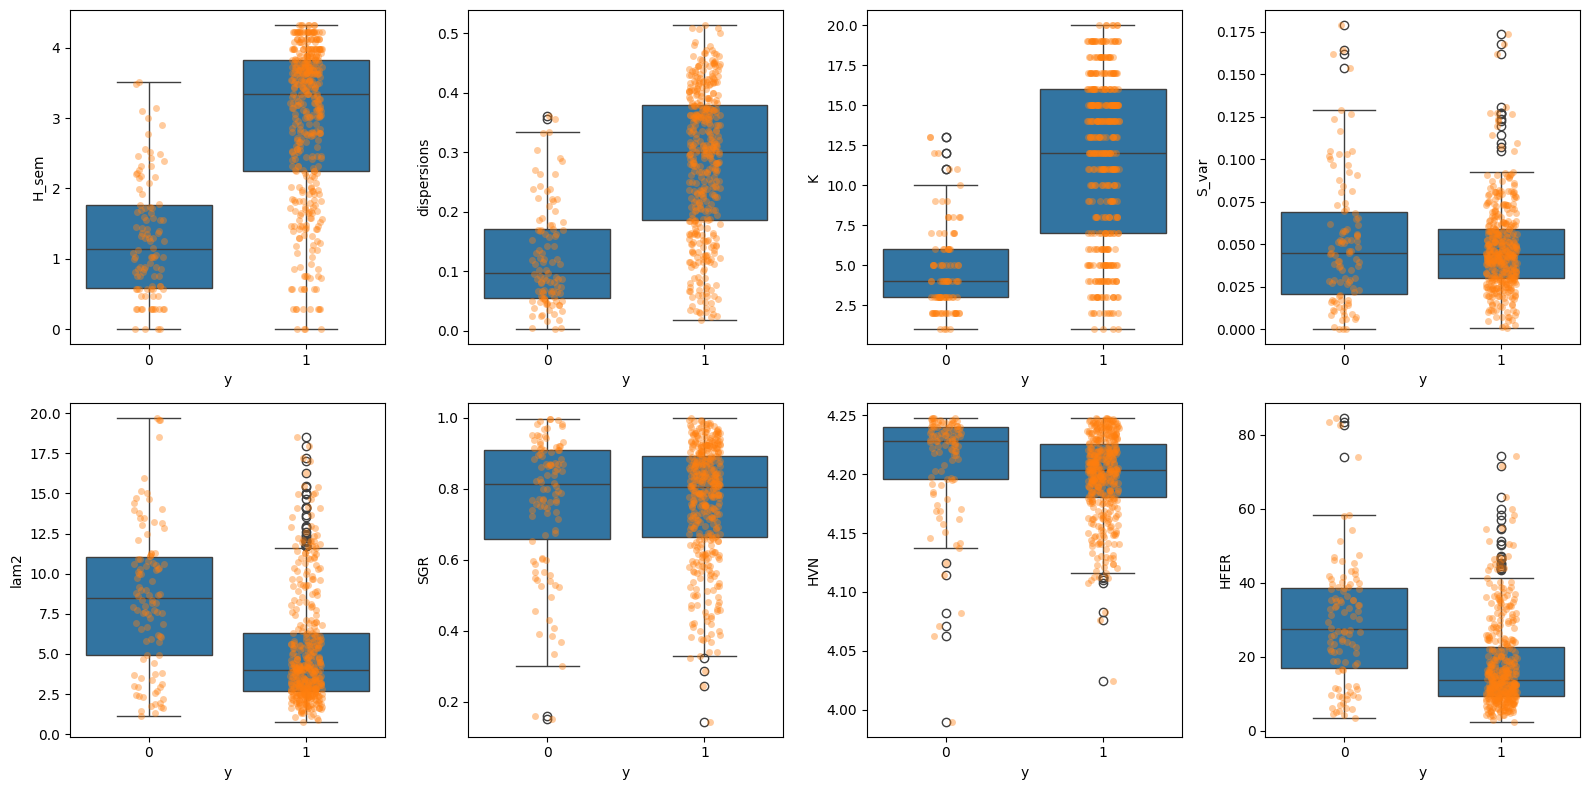

In [10]:
fig, axes = plt.subplots(2,4, figsize=(16,8))

for ax, f in zip(axes.flatten(), feature_names):
    sns.boxplot(data=df_eda, x="y", y=f, ax=ax)
    sns.stripplot(data=df_eda, x="y", y=f, ax=ax, alpha=0.4)

plt.tight_layout()
plt.show()

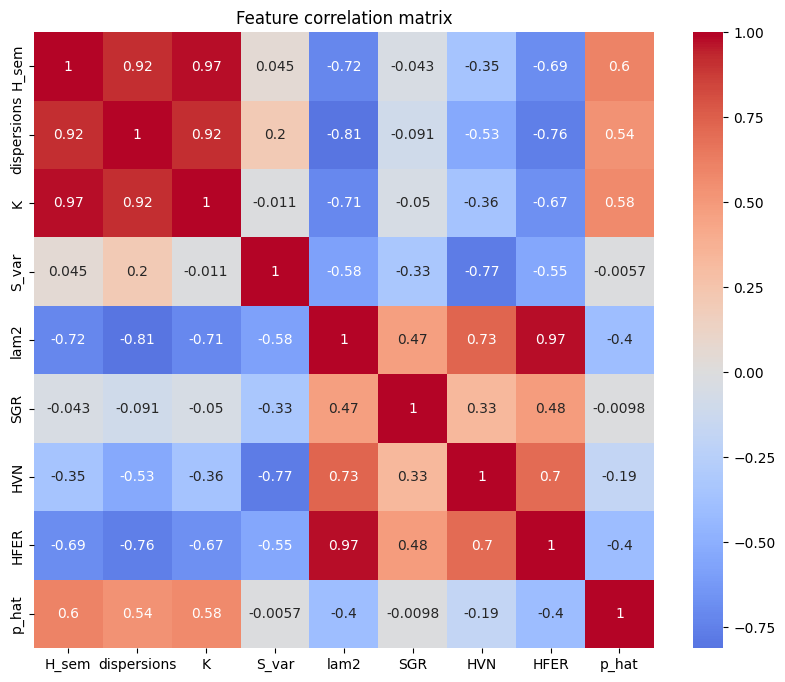

In [11]:
corr = df_eda[feature_names + ["p_hat"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature correlation matrix")
plt.show()

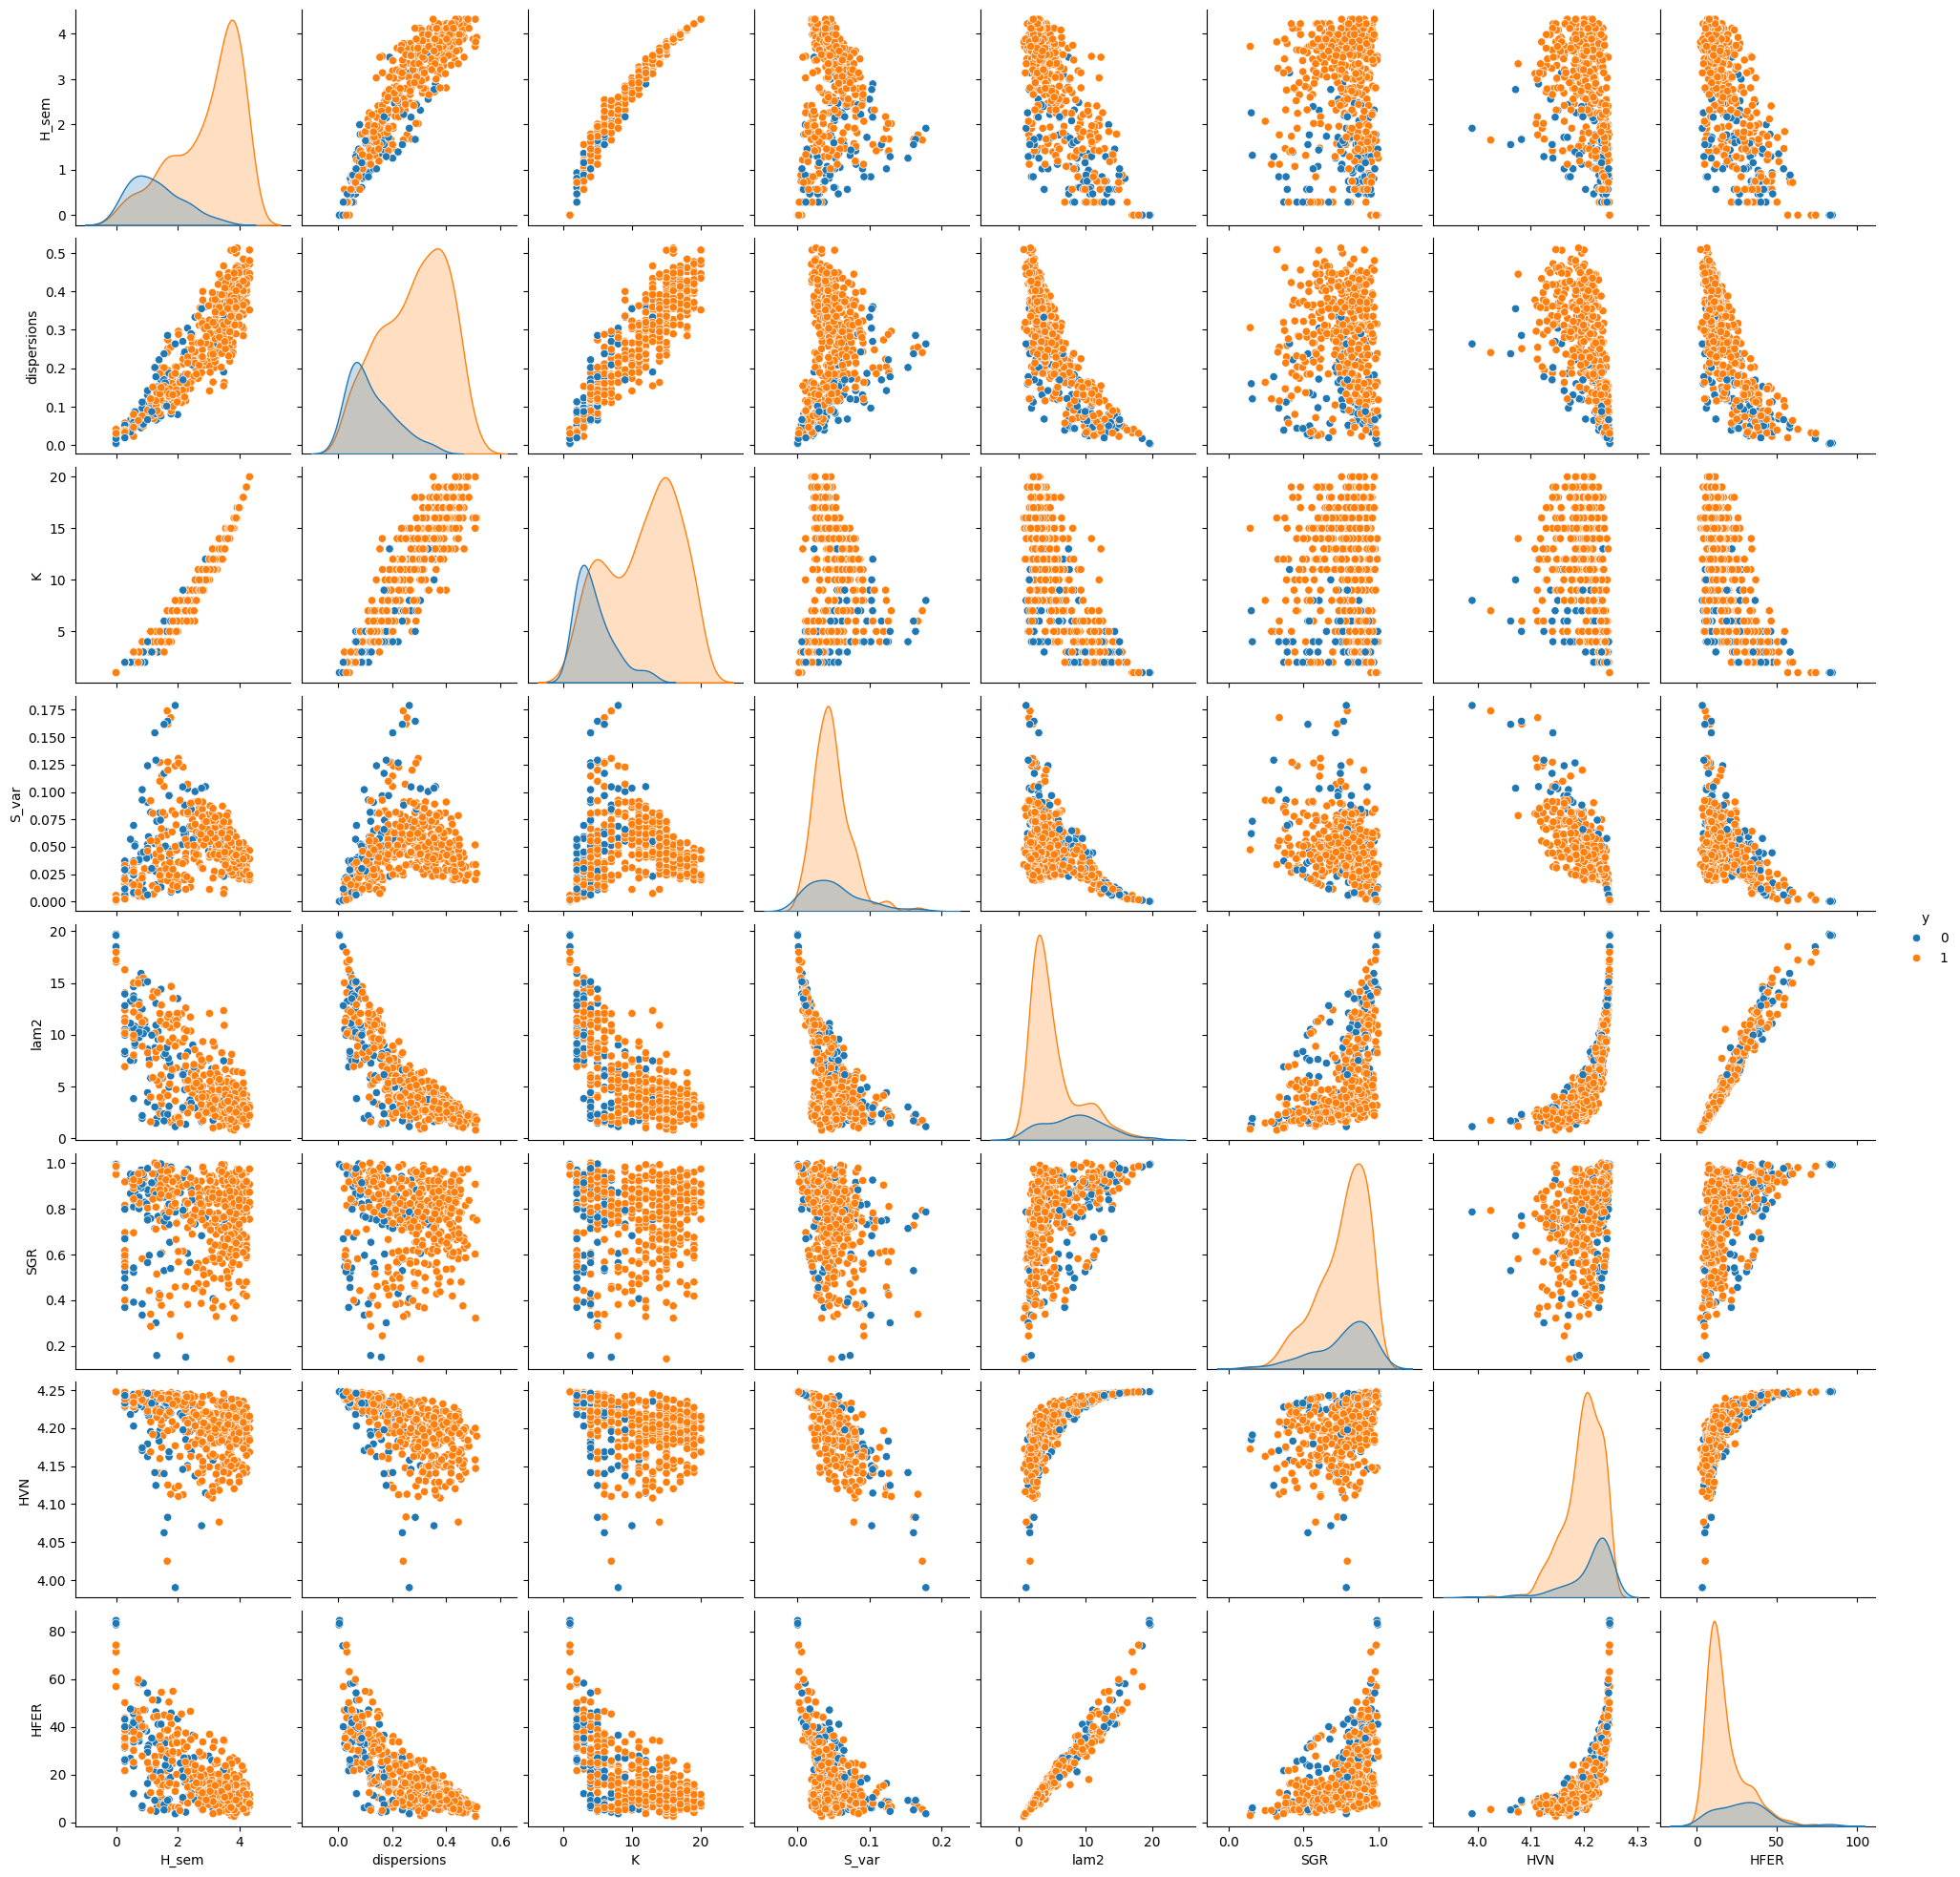

In [12]:
sns.pairplot(
    df_eda,
    vars=feature_names,
    hue="y",
    diag_kind="kde"
)

plt.show()

3. Now we evaluate and train a logistic regression model predicting y from X. We stratify the folds since the there is class imbalance in y.
   We use cross validation to evaluate since the dataset is pretty small.

In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = np.asarray(X)
y = np.asarray(y).astype(int)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

fixed_l1_ratio = 0.5

param_grid = {
    "clf__C": np.logspace(-3, 2, 11)
}

rows = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",
            max_iter=100000,
            tol=1e-4,
            l1_ratio=fixed_l1_ratio,
            C=1.0,
            random_state=0
        )),
    ])

    grid = GridSearchCV(
        pipe, param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(Xtr, ytr)

    best = grid.best_estimator_
    yprob = best.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(yte, yprob)

    beta = best.named_steps["clf"].coef_[0]
    intercept = best.named_steps["clf"].intercept_[0]

    row = {"fold": fold, "auc": auc, "best_C": grid.best_params_["clf__C"], "intercept": intercept}
    row.update({name: float(b) for name, b in zip(feature_names, beta)})
    rows.append(row)

coef_df = pd.DataFrame(rows)
print(coef_df)

print("Per-fold AUC:", np.round(coef_df["auc"].to_numpy(), 3))
print(f"Mean AUC: {coef_df['auc'].mean():.3f}  Std: {coef_df['auc'].std(ddof=1):.3f}")

summary = coef_df[feature_names].agg(["mean", "std"]).T
summary["abs_mean"] = summary["mean"].abs()
summary = summary.sort_values("abs_mean", ascending=False)

print("\nCoefficient stability (mean ± std across outer folds):")
print(summary[["mean", "std"]].round(4))

print("\nHow often each coefficient is exactly zero (sparsity check):")
zero_rate = (coef_df[feature_names] == 0.0).mean().sort_values(ascending=False)
print(zero_rate)

   fold       auc    best_C  intercept     H_sem  dispersions         K  \
0     1  0.936106  0.316228   2.247860  0.327076     1.182392  0.417095   
1     2  0.839060  0.100000   2.072974  0.742661     0.366145  0.547803   
2     3  0.890625  0.100000   2.042564  0.479815     0.506746  0.654996   
3     4  0.820000  0.100000   2.128776  0.697778     0.597274  0.471509   
4     5  0.880625  0.010000   1.399246  0.215238     0.041863  0.135735   

      S_var  lam2  SGR  HVN      HFER  
0 -0.522918   0.0  0.0  0.0  0.000000  
1 -0.285893   0.0  0.0  0.0  0.000000  
2 -0.301686   0.0  0.0  0.0 -0.010184  
3 -0.398237   0.0  0.0  0.0  0.000000  
4  0.000000   0.0  0.0  0.0  0.000000  
Per-fold AUC: [0.936 0.839 0.891 0.82  0.881]
Mean AUC: 0.873  Std: 0.046

Coefficient stability (mean ± std across outer folds):
               mean     std
dispersions  0.5389  0.4170
H_sem        0.4925  0.2286
K            0.4454  0.1948
S_var       -0.3017  0.1933
HFER        -0.0020  0.0046
lam2       

In [62]:
best_C = coef_df["best_C"].mean()

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        max_iter=100000,
        tol=1e-4,
        l1_ratio=0.5,
        C=best_C,
        random_state=0
    )),
])

final_model.fit(X, y)

beta = final_model.named_steps["clf"].coef_[0]

final_coef = pd.DataFrame({
    "feature": feature_names,
    "coefficient": beta
}).sort_values("coefficient", key=abs, ascending=False)

print(final_coef)

       feature  coefficient
1  dispersions     0.634922
0        H_sem     0.590105
2            K     0.583992
3        S_var    -0.392112
4         lam2     0.000000
5          SGR     0.000000
6          HVN     0.000000
7         HFER     0.000000


In [63]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_model,
    X,
    y,
    scoring="roc_auc",
    n_repeats=30,
    random_state=0
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

print(importance_df)

       feature  importance
1  dispersions    0.050533
0        H_sem    0.045573
2            K    0.038112
3        S_var    0.022538
4         lam2    0.000000
5          SGR    0.000000
6          HVN    0.000000
7         HFER    0.000000
